<a href="https://colab.research.google.com/github/Guthivarshini/sales-data-analysis/blob/main/Website_Traffic_Analysis_%26_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**🌐 Website Traffic Analysis & Prediction**

In today’s digital world, understanding how users interact with a website is essential for improving engagement and business performance. This project focuses on analyzing website traffic data to uncover meaningful patterns and predict future user activity.

The project began with raw traffic data containing daily website visits. I first performed data cleaning and preprocessing, ensuring the dataset was structured and ready for analysis. By converting date fields and organizing the data chronologically, I was able to explore how traffic changed over time.

Using data visualization techniques, I identified key trends such as peak traffic periods, average daily visits, and fluctuations in user engagement. These insights helped highlight when users are most active and how traffic behaves across different time periods.

To take the project further, I implemented a machine learning model using linear regression to predict future website traffic. By transforming dates into numerical values, the model was trained to learn patterns from historical data and generate predictions for upcoming days.

The results provided a clear view of expected traffic trends, enabling better planning for server capacity, marketing campaigns, and content scheduling.
Overall, this project demonstrates how data analysis and machine learning can be combined to transform raw website data into actionable insights, supporting smarter and more strategic decision-making.

**Analysis Code** (Visual + Insights)

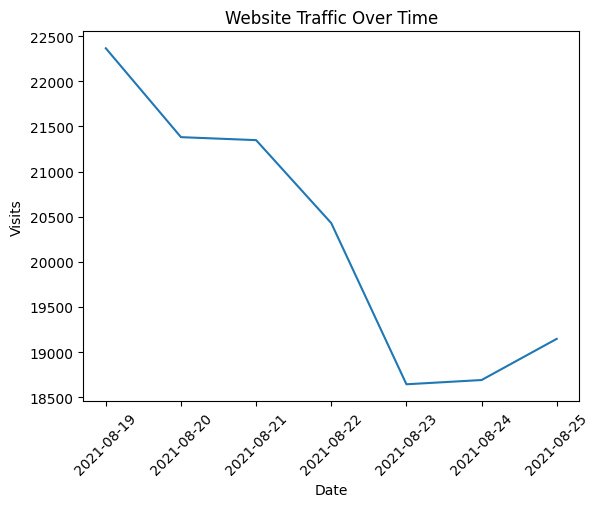

Average Daily Visits: 20287.85714285714
Peak Traffic Day:
 date      2021-08-19 00:00:00
visits                  22366
Name: 0, dtype: object


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('traffic.csv')

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Calculate daily visits (count of 'pageview' events)
daily_visits = df[df['event'] == 'pageview'].groupby('date').size().reset_index(name='visits')

# Merge daily_visits back to the original DataFrame or use it directly
# For plotting and calculations, we can use daily_visits directly as it already contains 'date' and 'visits'

# Sort values
daily_visits = daily_visits.sort_values('date')

# Plot traffic over time
plt.figure()
plt.plot(daily_visits['date'], daily_visits['visits'])
plt.title('Website Traffic Over Time')
plt.xlabel('Date')
plt.ylabel('Visits')
plt.xticks(rotation=45)
plt.show()

# Daily average
avg_visits = daily_visits['visits'].mean()
print("Average Daily Visits:", avg_visits)

# Peak day
peak_day = daily_visits.loc[daily_visits['visits'].idxmax()]
print("Peak Traffic Day:\n", peak_day)

**Bar Chart** (Traffic by Month)

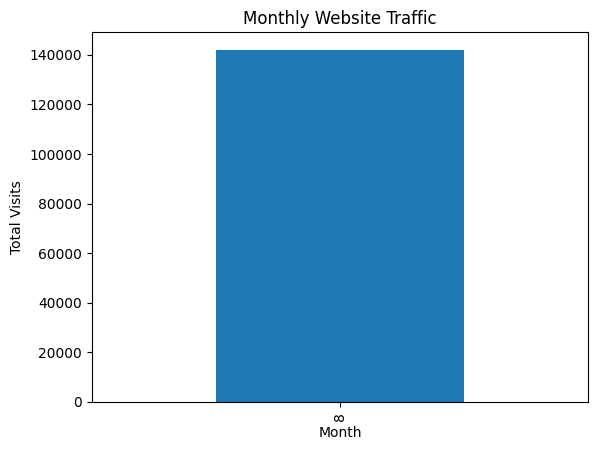

2021-08-19 00:00:00 2021-08-25 00:00:00
[8]


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('traffic.csv')

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Calculate daily visits (count of 'pageview' events)
daily_visits_df = df[df['event'] == 'pageview'].groupby('date').size().reset_index(name='visits')

# Create Month column from the daily visits DataFrame
daily_visits_df['Month'] = daily_visits_df['date'].dt.month

# Group by month from the daily visits DataFrame
monthly_visits = daily_visits_df.groupby('Month')['visits'].sum()

# Bar chart
plt.figure()
monthly_visits.plot(kind='bar')
plt.title('Monthly Website Traffic')
plt.xlabel('Month')
plt.ylabel('Total Visits')
plt.show()

print(df['date'].min(), df['date'].max())
print(daily_visits_df['Month'].unique())

**Pie Chart** (Traffic Distribution by Month)

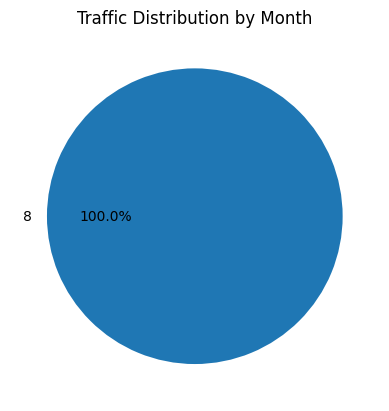

2021-08-19 00:00:00 2021-08-25 00:00:00
[8]


In [16]:
# Pie chart
plt.figure()
monthly_visits.plot(kind='pie', autopct='%1.1f%%')
plt.title('Traffic Distribution by Month')
plt.ylabel('')  # removes extra label
plt.show()
print(df['date'].min(), df['date'].max())
print(daily_visits_df['Month'].unique())

**Prediction Code **(Machine Learning)

In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# Load data
df_raw = pd.read_csv('traffic.csv')

# Convert date to datetime
df_raw['date'] = pd.to_datetime(df_raw['date'])

# Calculate daily visits (count of 'pageview' events)
daily_visits_df = df_raw[df_raw['event'] == 'pageview'].groupby('date').size().reset_index(name='visits')

# Convert date to numeric (days since first date) for the daily_visits_df
daily_visits_df['days'] = (daily_visits_df['date'] - daily_visits_df['date'].min()).dt.days

# Features and target
X = daily_visits_df[['days']]
y = daily_visits_df['visits']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 7 days
future_days = np.array(range(daily_visits_df['days'].max()+1, daily_visits_df['days'].max()+8)).reshape(-1,1)
predictions = model.predict(future_days)

print("Next 7 days predictions:", predictions)

Next 7 days predictions: [17754.71428571 17121.42857143 16488.14285714 15854.85714286
 15221.57142857 14588.28571429 13955.        ]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
